In [18]:
import json
import os
from pathlib import Path
import pickle as pkl
from pprint import pprint
import sys

dirpath_root = Path().resolve().parents[1]
sys.path.append(str(dirpath_root))

import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import iirpeak, tf2sos, sosfiltfilt, hilbert
from scipy.signal import detrend
import xarray as xr

import analysis.ou_tuning.netpyne_res_parse_utils as parse_utils
import analysis.ou_tuning.data_proc_utils as proc_utils
from analysis.xr_proc import xr_proc, xr_epoch

In [19]:
def sim_res_to_xr_LFP(sim_res):
    lfp, tt, lfp_coords = parse_utils.get_lfp(sim_res)
    dims = ['y', 'time']
    coords = {'y': lfp_coords[:, 1], 'time': tt / 1000}
    return xr.DataArray(lfp, dims=dims, coords=coords)

In [20]:
exp_group = 'single_model1'
exp_name = 'model1_pulses_tc_itp4'

exp_name_sub = (
    'exp_t_23.0_25.0_mu_-2.32_sigma_2.81_d_200_T_1000_c_40_w_0.075_r_5000_0_t0_3000_jit_0'
    #'exp_t_23.0_25.0_mu_1.0_sigma_0.07_d_200_T_1000_c_40_w_0.075_r_500_250_t0_3000_jit_0'
    #'exp_t_48.0_50.0_mu_-2.32_sigma_2.81_d_200_T_1000_c_40_w_0.075_r_1250_0_t0_3000_jit_0'
    #'exp_t_48.0_50.0_mu_-2.32_sigma_2.81_d_200_T_1000_c_40_w_0.075_r_2500_0_t0_3000_jit_0'
)

dirpath_cfg = dirpath_root / 'exp_configs' / exp_group / exp_name
dirpath_res = dirpath_root / 'exp_results' / exp_group / exp_name / exp_name_sub

# Load sim results
fpath_pkl = dirpath_res / f'{exp_name}_data.pkl'
with open(fpath_pkl, 'rb') as fid:
    sim_res = pkl.load(fid)

In [21]:
# Load config
fpath_netpar = dirpath_res / f'{exp_name}_netParams.json'
with open(fpath_netpar, 'r') as fid:
    par = json.load(fid)

# Extract pulse times and rates
pulses = par['net']['params']['popParams']['PulseSeq']['params']['pulses']
pulse_times = [p['start'] / 1000 for p in pulses]
pulse_rates = [p['rate'] for p in pulses]
#pulse_times
#pulse_rates

In [22]:
# LFP and CSD
Xlfp = sim_res_to_xr_LFP(sim_res)
Xcsd = xr_proc.calc_xr_diff(Xlfp, n=2)

# Median filer
Xcsd = Xcsd.rolling(time=3, center=True).median()

# Epoch CSD data
trial_win = (-0.2, 0.5)
Xcsd_ep = xr_epoch.epoch_xr_data(Xcsd, pulse_times, trial_win)
#Xcsd_ep

Text(0.5, 1.0, 'CSD, y=1900')

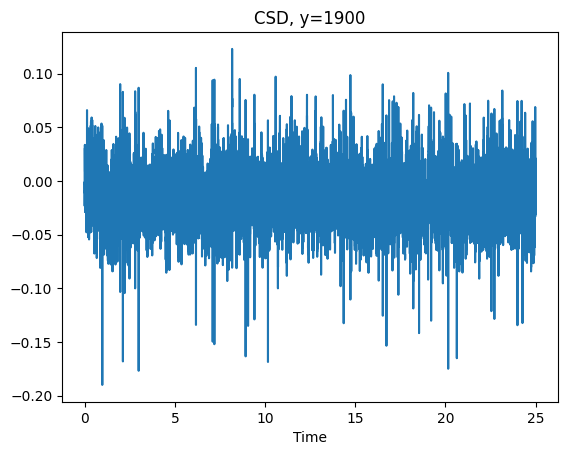

In [23]:
# Test plot CSD
ch = 19
plt.figure()
plt.plot(Xcsd.time, Xcsd.isel(y=10))
plt.xlabel('Time')
plt.title(f'CSD, y={Xcsd.y[ch].item()}')

Text(0.5, 0, 'Time')

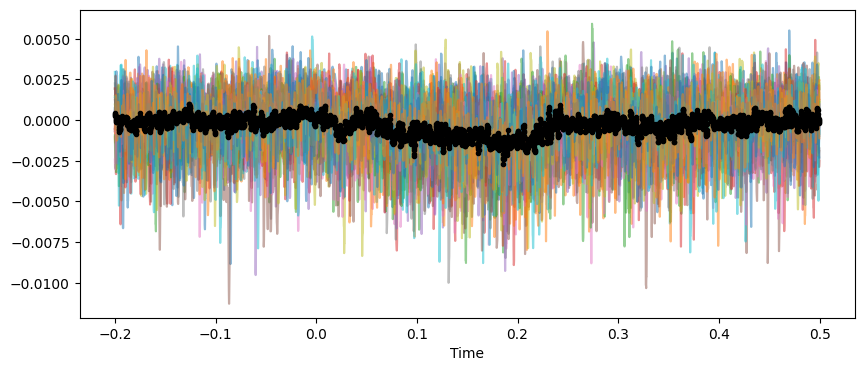

In [24]:
# Baseline correction
bl_win = (-0.2, 0)
Xcsd_ep_bl = Xcsd_ep.sel(time=slice(*bl_win)).mean(dim='time')
Xcsd_ep_ = Xcsd_ep - Xcsd_ep_bl.mean(dim='trial')

ch = 3
plt.figure(figsize=(10, 4))
for n in range(Xcsd_ep_.trial.size):
    plt.plot(Xcsd_ep_.time, Xcsd_ep_.isel(trial=n, y=ch), alpha=0.5)
plt.plot(Xcsd_ep_.time, Xcsd_ep_.isel(y=ch).mean(dim='trial'), 'k.-')
plt.xlabel('Time')
#plt.ylim(-0.05, 0.1)
#plt.xlim(0, 0.2)

Text(0.5, 1.0, 'CSD')

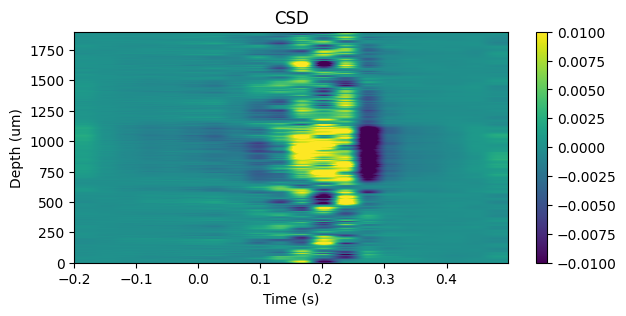

In [25]:
Xcsd_avg = Xcsd_ep_.mean(dim='trial')

plt.figure(figsize=(7, 3))
vmax = 0.01
plt.imshow(
    Xcsd_avg.T,
    aspect='auto',
    extent=[Xcsd_avg.time.min(), Xcsd_avg.time.max(), Xcsd_avg.y.min(), Xcsd_avg.y.max()],
    origin='lower',
    vmin=-vmax, vmax=vmax
)
plt.colorbar()
plt.xlabel('Time (s)')
plt.ylabel('Depth (um)')
plt.title('CSD')

Text(0.5, 1.0, 'Firing rate, TC')

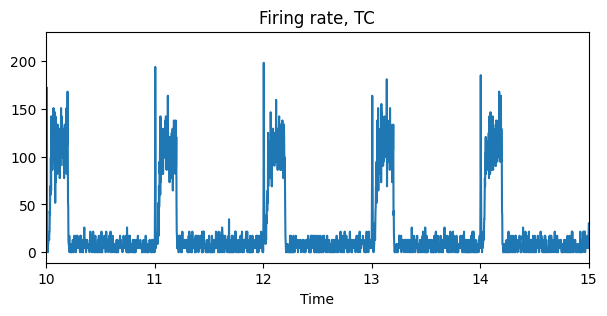

In [26]:
T = parse_utils.get_sim_duration(sim_res)
ncells = parse_utils.get_net_size(sim_res)
pops_active = sim_res['simConfig']['subnet_params']['pops_active']

spike_data = parse_utils.get_net_spikes(
    sim_res, pop_names=pops_active)
rate_data = proc_utils.calc_net_rate_dynamics(
    spike_data, ncells=ncells,
    time_range=(3, T), dt_bin=2e-3
)
# -> dict[str, tuple[np.ndarray, list[np.ndarray] | np.ndarray]]:

# Convert rate_data -> xarray DataArray with dims ('pop', 'time')
pops = list(rate_data.keys())
R = []
for pop in pops:
    # Extract spikes and calc rate dynacmics
    t, r = rate_data[pop]
    R.append(r)
R = xr.DataArray(
    np.vstack(R),
    dims=('pop', 'time'),
    coords={'pop': pops, 'time': t}
)

plt.figure(figsize=(7, 3))
pop_vis = 'TC'
plt.plot(R.time, R.sel(pop=pop_vis))
plt.xlim(10, 15)
plt.xlabel('Time')
plt.title(f'Firing rate, {pop_vis}')
#plt.yscale('log')

In [27]:
# Epoch firing rates
trial_win = (-0.2, 0.5)
R_ep = xr_epoch.epoch_xr_data(R, pulse_times, trial_win)

# Attach pulse rate coord
mask = [t in R_ep.ev_time for t in pulse_times]
pr = np.asarray(pulse_rates)[mask]
R_ep = R_ep.assign_coords({'pulse_r': ('trial', pr)})
R_ep

<xarray.DataArray (trial: 21, pop: 2, time: 351)> Size: 118kB
array([[[17.24137931,  0.        , 12.93103448, ...,  0.        ,
          8.62068966, 21.55172414],
        [ 0.59737157,  1.19474313,  1.19474313, ...,  1.19474313,
          1.7921147 ,  0.59737157]],

       [[ 4.31034483,  4.31034483,  4.31034483, ...,  8.62068966,
          4.31034483,  0.        ],
        [ 1.19474313,  1.19474313,  1.7921147 , ...,  4.18160096,
          1.7921147 ,  1.19474313]],

       [[ 4.31034483,  0.        ,  4.31034483, ...,  0.        ,
          4.31034483, 21.55172414],
        [ 4.18160096,  1.19474313,  2.38948626, ...,  2.38948626,
          1.19474313,  0.59737157]],

       ...,

       [[ 4.31034483,  8.62068966,  8.62068966, ...,  4.31034483,
          4.31034483, 17.24137931],
        [ 1.7921147 ,  2.38948626,  2.98685783, ...,  0.59737157,
          3.58422939,  3.58422939]],

       [[12.93103448,  4.31034483,  0.        , ...,  4.31034483,
          4.31034483, 12.93103448],
        [ 0.59737157,  1.19474313,  1.7921147 , ...,  2.38948626,
          3.58422939,  1.19474313]],

       [[ 4.31034483,  4.31034483,  0.        , ...,  4.31034483,
          0.        ,  4.31034483],
        [ 0.59737157,  3.58422939,  2.38948626, ...,  1.7921147 ,
          1.19474313,  2.38948626]]], shape=(21, 2, 351))
Coordinates:
  * trial    (trial) int64 168B 0 1 2 3 4 5 6 7 8 ... 12 13 14 15 16 17 18 19 20
    ev_time  (trial) float64 168B 4.0 5.0 6.0 7.0 8.0 ... 21.0 22.0 23.0 24.0
  * pop      (pop) <U4 32B 'TC' 'ITP4'
  * time     (time) float64 3kB -0.2 -0.198 -0.196 -0.194 ... 0.496 0.498 0.5
    pulse_r  (trial) int64 168B 5000 5000 5000 5000 5000 ... 5000 5000 5000 5000

Text(0.5, 1.0, 'Firing rate')

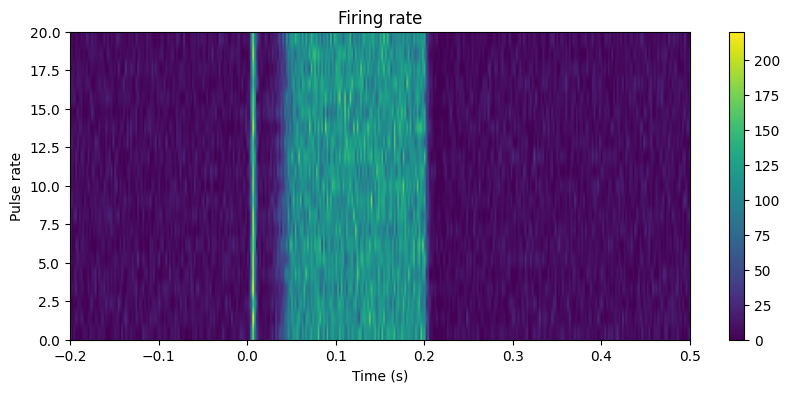

In [28]:
R_ = R_ep.sel(pop='TC')

plt.figure(figsize=(10, 4))
#vmax = 0.02
plt.imshow(
    R_,
    aspect='auto',
    extent=[R_.time.min(), R_.time.max(),
            #R_.pulse_r.min(), R_.pulse_r.max()],
            R_.trial.min(), R_.trial.max()],
    origin='lower',
    #vmin=-vmax, vmax=vmax
)
plt.colorbar()
plt.xlabel('Time (s)')
plt.ylabel('Pulse rate')
plt.title('Firing rate')

ValueError: x and y must have same first dimension, but have shapes (351,) and (1,)

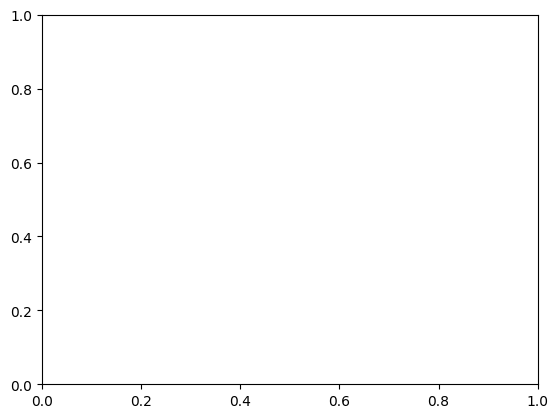

In [29]:
plt.figure()
plt.plot(R_.time, R_.mean())

Text(0.5, 1.0, 'Firing rate for pulse_r=2000')

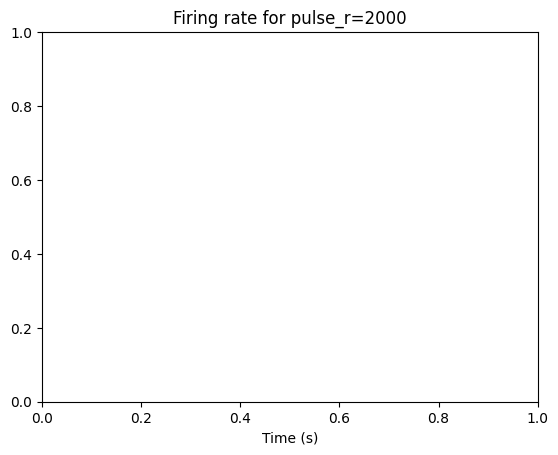

In [ ]:
plt.figure()
#R_ = R_.set_index(trial='pulse_r').reindex()
# find the trial index corresponding to pulse rate 2000 and plot that trial
#trial_idx = int(np.where(pr == 2000)[0][0])
#plt.plot(R_.time, R_.isel(trial=trial_idx))
plt.xlabel('Time (s)')
plt.title('Firing rate for pulse_r=2000')